In [1]:
import tensorflow as tf
from keras import layers,models,preprocessing
import numpy as np
import os
import matplotlib.pyplot as plt


In [2]:
DATA_DIR="celebA"
IMG_HEIGHT=64
IMG_WIDTH=64
BATCH_SIZE=128
BUFFER_SIZE=60000

In [3]:
def load_image(image_path):
    image=tf.io.read_file(image_path)
    image=tf.image.decode_jpeg(image, channels=3)
    image=tf.image.resize(image, [IMG_HEIGHT,IMG_WIDTH])
    image=(image-127.5)/127.5
    return image

In [4]:
def load_dataset(data_dir):
    image_paths=[os.path.join(data_dir,img) for img in os.listdir(data_dir)]
    image_dataset=tf.data.Dataset.from_tensor_slices(image_paths)
    image_dataset=image_dataset.map(load_image,num_parallel_calls=tf.data.experimental.AUTOTUNE)
    image_dataset=image_dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE).prefetch(tf.data.experimental.AUTOTUNE)
    return image_dataset

In [5]:
train_dataset=load_dataset(DATA_DIR)

In [6]:
def build_generator():
    model = models.Sequential()
    model.add(layers.Dense(8 * 8 * 256, use_bias=False, input_shape=(100,)))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    model.add(layers.Reshape((8, 8, 256)))
    assert model.output_shape == (None, 8, 8, 256) # Убедитесь, что выходная форма такая
    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(2, 2), padding='same',
    use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    assert model.output_shape == (None, 16, 16, 128)
    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same',
    use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())
    assert model.output_shape == (None, 32, 32, 64)
    model.add(layers.Conv2DTranspose(3, (5, 5), strides=(2, 2), padding='same', use_bias=False,activation='tanh'))
    assert model.output_shape == (None, 64, 64, 3)
    return model


In [7]:
def build_discriminator():
    model = models.Sequential()
    model.add(layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same', input_shape=[64, 64, 3]))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))
    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))
    model.add(layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation='sigmoid'))
    return model

In [11]:
generator=build_generator()
discriminator=build_discriminator()
cross_entropy =tf._losses.BinaryCrossentropy(from_logits=True)

In [8]:
def discriminator_loss(real_output, fake_output):
    real_loss = cross_entropy(tf.ones_like(real_output), real_output)
    fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
    total_loss = real_loss + fake_loss
    return total_loss

In [9]:
def generator_loss(fake_output):
    return cross_entropy(tf.ones_like(fake_output), fake_output)

In [12]:
generator_optimizer = tf._optimizers.Adam(1e-4)
discriminator_optimizer = tf._optimizers.Adam(1e-4)

In [13]:
@tf.function
def train_step(images):
    noise = tf.random.normal([BATCH_SIZE, 100])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
        gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
        gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
        generator_optimizer.apply_gradients(zip(gradients_of_generator,
        generator.trainable_variables))
        discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator,
        discriminator.trainable_variables))

In [14]:
def train(dataset, epochs):
    for epoch in range(epochs):
        for image_batch in dataset:
            train_step(image_batch)
        print(f'Эпоха {epoch + 1} завершена')
        if (epoch + 1) % 10 == 0:
            noise = tf.random.normal([16, 100])
            generate_and_save_images(generator, epoch + 1, noise)

C:\ProgramData\anaconda3\Lib\site-packages\keras\src\backend\tensorflow\nn.py:1286: UserWarning: "`binary_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Sigmoid activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


Эпоха 1 завершена
Эпоха 2 завершена
Эпоха 3 завершена
Эпоха 4 завершена
Эпоха 5 завершена
Эпоха 6 завершена
Эпоха 7 завершена
Эпоха 8 завершена
Эпоха 9 завершена
Эпоха 10 завершена


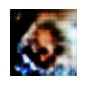

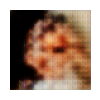

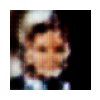

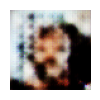

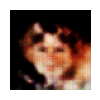

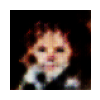

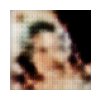

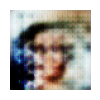

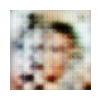

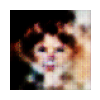

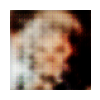

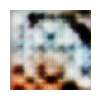

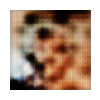

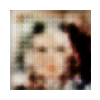

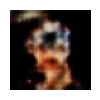

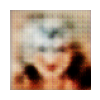

Эпоха 11 завершена
Эпоха 12 завершена
Эпоха 13 завершена
Эпоха 14 завершена
Эпоха 15 завершена
Эпоха 16 завершена
Эпоха 17 завершена
Эпоха 18 завершена
Эпоха 19 завершена
Эпоха 20 завершена


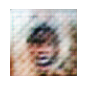

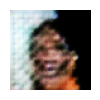

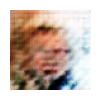

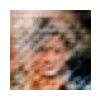

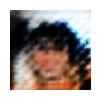

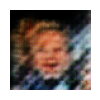

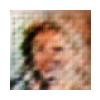

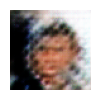

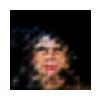

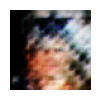

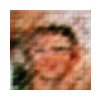

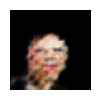

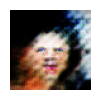

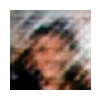

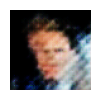

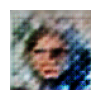

Эпоха 21 завершена
Эпоха 22 завершена
Эпоха 23 завершена
Эпоха 24 завершена
Эпоха 25 завершена
Эпоха 26 завершена
Эпоха 27 завершена
Эпоха 28 завершена
Эпоха 29 завершена
Эпоха 30 завершена


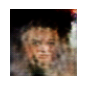

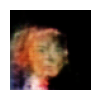

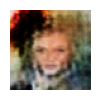

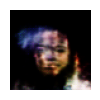

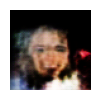

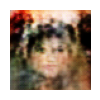

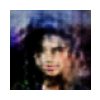

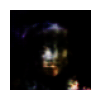

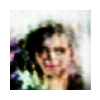

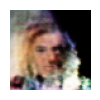

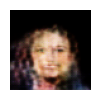

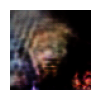

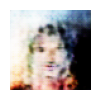

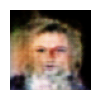

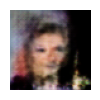

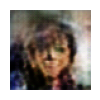

Эпоха 31 завершена
Эпоха 32 завершена
Эпоха 33 завершена
Эпоха 34 завершена
Эпоха 35 завершена
Эпоха 36 завершена
Эпоха 37 завершена
Эпоха 38 завершена
Эпоха 39 завершена
Эпоха 40 завершена


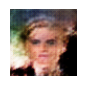

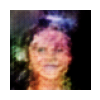

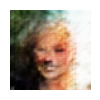

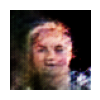

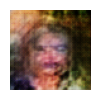

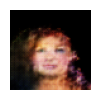

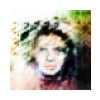

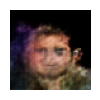

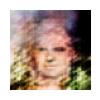

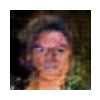

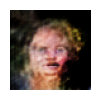

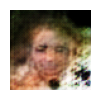

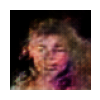

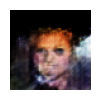

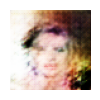

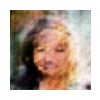

Эпоха 41 завершена
Эпоха 42 завершена
Эпоха 43 завершена
Эпоха 44 завершена
Эпоха 45 завершена
Эпоха 46 завершена
Эпоха 47 завершена
Эпоха 48 завершена
Эпоха 49 завершена
Эпоха 50 завершена


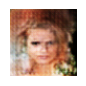

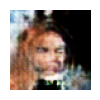

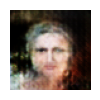

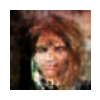

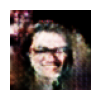

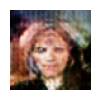

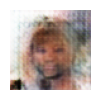

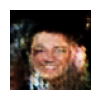

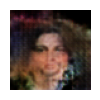

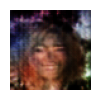

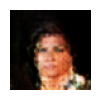

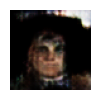

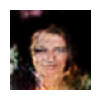

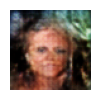

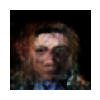

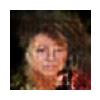

Эпоха 51 завершена
Эпоха 52 завершена
Эпоха 53 завершена
Эпоха 54 завершена
Эпоха 55 завершена
Эпоха 56 завершена
Эпоха 57 завершена
Эпоха 58 завершена
Эпоха 59 завершена
Эпоха 60 завершена


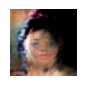

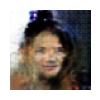

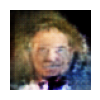

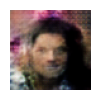

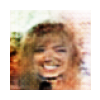

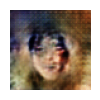

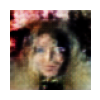

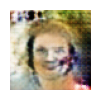

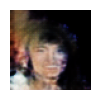

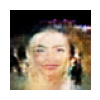

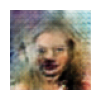

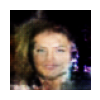

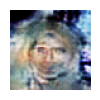

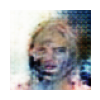

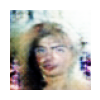

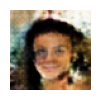

Эпоха 61 завершена
Эпоха 62 завершена
Эпоха 63 завершена
Эпоха 64 завершена
Эпоха 65 завершена
Эпоха 66 завершена
Эпоха 67 завершена
Эпоха 68 завершена
Эпоха 69 завершена
Эпоха 70 завершена


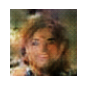

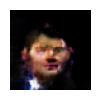

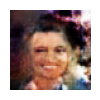

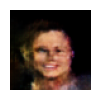

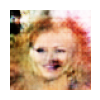

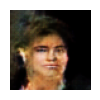

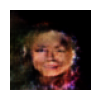

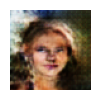

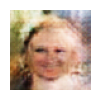

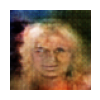

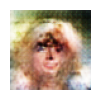

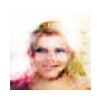

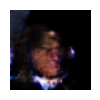

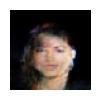

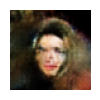

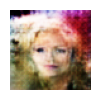

Эпоха 71 завершена
Эпоха 72 завершена
Эпоха 73 завершена
Эпоха 74 завершена
Эпоха 75 завершена
Эпоха 76 завершена
Эпоха 77 завершена
Эпоха 78 завершена
Эпоха 79 завершена
Эпоха 80 завершена


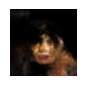

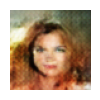

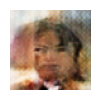

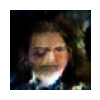

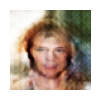

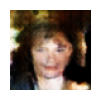

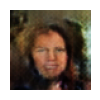

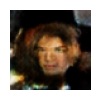

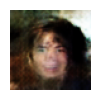

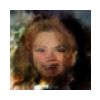

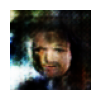

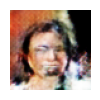

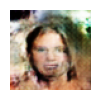

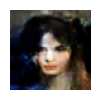

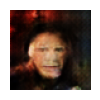

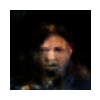

Эпоха 81 завершена
Эпоха 82 завершена
Эпоха 83 завершена
Эпоха 84 завершена
Эпоха 85 завершена
Эпоха 86 завершена
Эпоха 87 завершена
Эпоха 88 завершена


In [16]:
EPOCHS = 88
train(train_dataset, EPOCHS)

In [15]:
def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)
    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow((predictions[i] * 127.5 + 127.5).numpy().astype(np.uint8))
        plt.axis('off')
        plt.savefig(f'image_at_epoch_{epoch:04d}.png')
        plt.show()

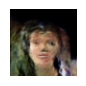

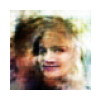

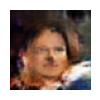

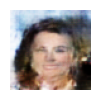

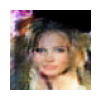

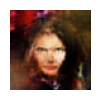

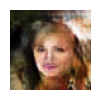

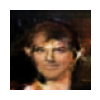

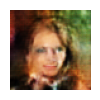

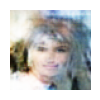

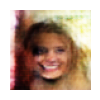

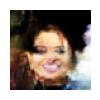

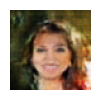

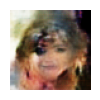

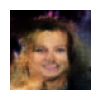

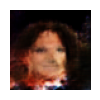

In [32]:
noise = tf.random.normal([16, 100])
generate_and_save_images(generator, 1, noise)